# Morfología matemática para limpieza de máscaras

En este cuaderno vas a usar operaciones morfológicas para limpiar máscaras binarias. La idea central es entender qué pasa cuando expandís, reducís, abrís o cerrás regiones de una imagen binaria.


## Objetivo

Comprender cómo las operaciones morfológicas modifican la forma de una máscara y por qué conviene elegir una u otra según el tipo de defecto que querés corregir.

## Resultados de aprendizaje

Al finalizar este cuaderno, vas a poder:

- distinguir erosión y dilatación;
- explicar qué problema intenta resolver la apertura y qué problema intenta resolver la clausura;
- limpiar una máscara sintética y otra obtenida de una imagen real;
- describir el efecto del tamaño del kernel sobre el resultado.

## Relación con la secuencia

Este cuaderno continúa el trabajo con máscaras y prepara el terreno para contornos y mediciones geométricas. Si la máscara está mal, casi todo lo que sigue también queda mal.


## Módulos que vamos a usar

- `cv2`: para aplicar operaciones morfológicas y umbralizar imágenes.
- `numpy`: para construir una máscara sintética y definir kernels.
- `matplotlib.pyplot`: para comparar resultados.
- `pathlib.Path`: para leer una imagen real.


In [7]:
# Se importan módulos para manejar rutas, procesar imágenes,
# trabajar con matrices y visualizar comparaciones.
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt


## 1. Empezar con una máscara controlada

Primero conviene trabajar sobre una máscara sintética. Así podemos ver con claridad qué cambia en la forma sin que aparezcan otros problemas de segmentación mezclados.


In [8]:
# Se crea una máscara vacía que servirá como escenario controlado.
mascara_base = np.zeros((260, 420), dtype=np.uint8)

# Se dibujan dos regiones simples para que el efecto morfológico
# sea fácil de interpretar visualmente.
cv2.rectangle(mascara_base, (40, 60), (170, 190), 255, -1)
cv2.circle(mascara_base, (290, 130), 55, 255, -1)

# Se usa random estándar para evitar numpy.random en este entorno.
import random

# La máscara ruidosa parte de la base y luego se altera con defectos sintéticos.
mascara_ruidosa = mascara_base.copy()
random.seed(7)

# Se eligen 400 posiciones aleatorias para simular puntitos blancos aislados.
indices_ruido = random.sample(range(mascara_ruidosa.size), 400)

# np.unravel_index transforma índices lineales en coordenadas (fila, columna).
filas_ruido, columnas_ruido = np.unravel_index(indices_ruido, mascara_ruidosa.shape)

for fila, columna in zip(filas_ruido, columnas_ruido):
    mascara_ruidosa[fila, columna] = 255

# Se agregan huecos negros dentro de las regiones para que la clausura
# tenga un problema concreto que resolver.
cv2.circle(mascara_ruidosa, (110, 130), 18, 0, -1)
cv2.circle(mascara_ruidosa, (290, 130), 10, 0, -1)


array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(260, 420), dtype=uint8)

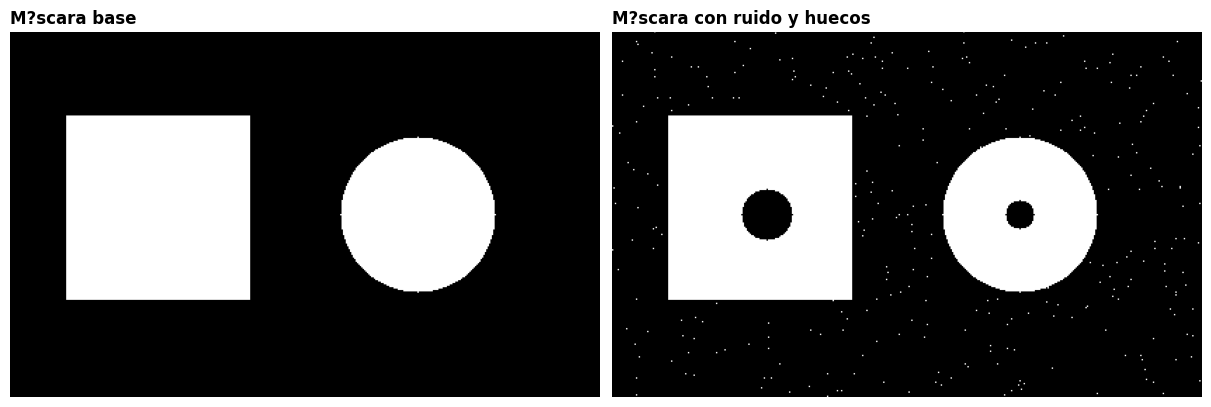

In [9]:
# Se comparan la máscara limpia y la máscara degradada
# para identificar visualmente ruido puntual y huecos internos.
fig, ejes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
ejes[0].imshow(mascara_base, cmap="gray")
ejes[0].set_title("Máscara base", fontweight="bold", loc="left")
ejes[0].axis("off")
ejes[1].imshow(mascara_ruidosa, cmap="gray")
ejes[1].set_title("Máscara con ruido y huecos", fontweight="bold", loc="left")
ejes[1].axis("off")
plt.show()


## 2. Erosión y dilatación

La erosión tiende a reducir regiones blancas. La dilatación tiende a expandirlas. Mirarlas por separado ayuda a entender qué hacen antes de combinarlas.


El kernel es una matriz pequeña que se usa como “ventana de trabajo” para recorrer la imagen y decidir cómo modificar cada píxel.

En morfología matemática, el kernel define:

el tamaño de la vecindad que se observa,
la forma de esa vecindad,
y qué tan fuerte será el efecto de erosión, dilatación, apertura o clausura.

Ejemplo:

kernel = np.ones((5, 5), dtype=np.uint8)

Eso crea un kernel cuadrado de 5x5. Significa que cada operación mira un bloque de 5 por 5 píxeles alrededor de cada punto.

Intuición:

kernel chico: cambios más suaves y localizados,
kernel grande: cambios más fuertes, pero puede deformar más la forma original.



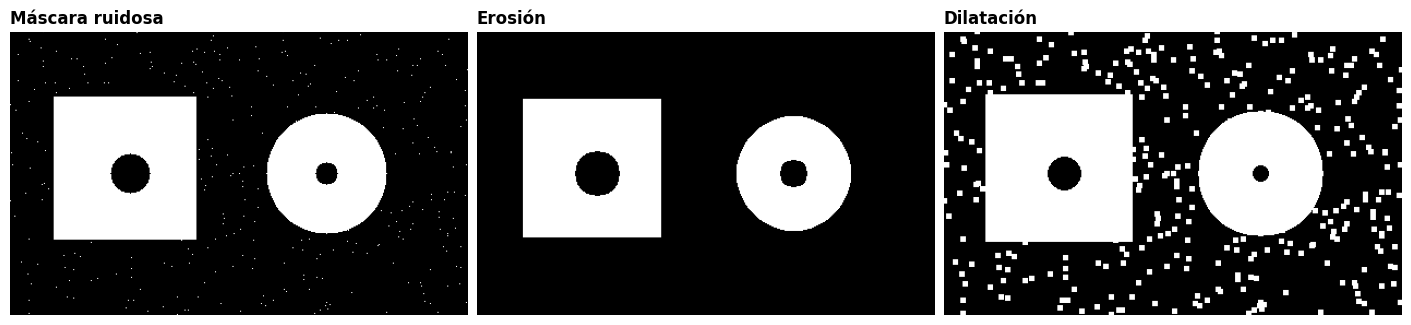

In [ ]:
# El kernel define el tamaño de la vecindad con la que operan
# la erosión y la dilatación.
kernel = np.ones((5, 5), dtype=np.uint8)

# La erosión reduce regiones blancas y puede eliminar detalles pequeños.
mascara_erosion = cv2.erode(mascara_ruidosa, kernel, iterations=1)

# La dilatación expande regiones blancas y puede cerrar huecos chicos
# o unir zonas cercanas.
mascara_dilatacion = cv2.dilate(mascara_ruidosa, kernel, iterations=1)

fig, ejes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)
ejes[0].imshow(mascara_ruidosa, cmap="gray")
ejes[0].set_title("M?scara ruidosa", fontweight="bold", loc="left")
ejes[0].axis("off")
ejes[1].imshow(mascara_erosion, cmap="gray")
ejes[1].set_title("Erosi?n", fontweight="bold", loc="left")
ejes[1].axis("off")
ejes[2].imshow(mascara_dilatacion, cmap="gray")
ejes[2].set_title("Dilataci?n", fontweight="bold", loc="left")
ejes[2].axis("off")
plt.show()

# en la erosión, el kernel hace que las regiones blancas se achiquen;
# en la dilatación, hace que se agranden;
# en la apertura, ayuda a sacar ruido pequeño;
# en la clausura, ayuda a cerrar huecos pequeños.


## 3. Apertura y clausura

La apertura suele servir para eliminar ruido pequeño. La clausura suele servir para cerrar huecos o unir regiones cercanas. Ahora vamos a ver ambas sobre la misma máscara.


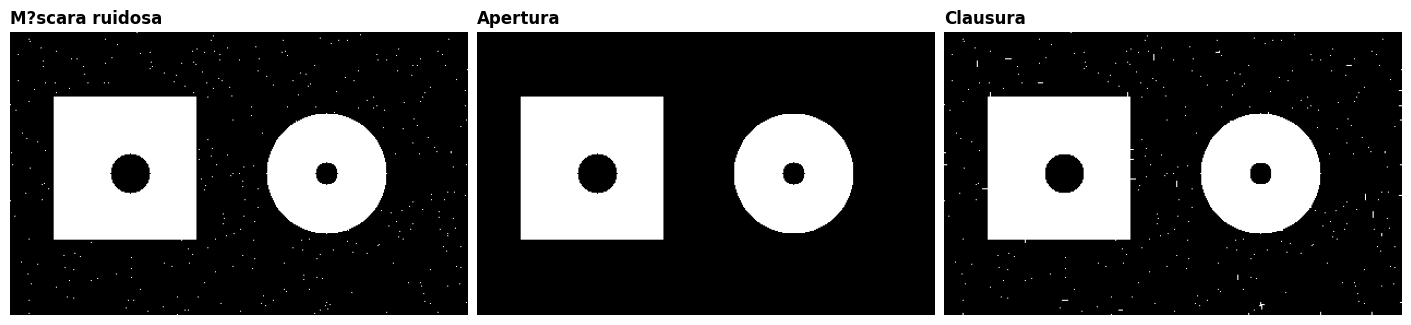

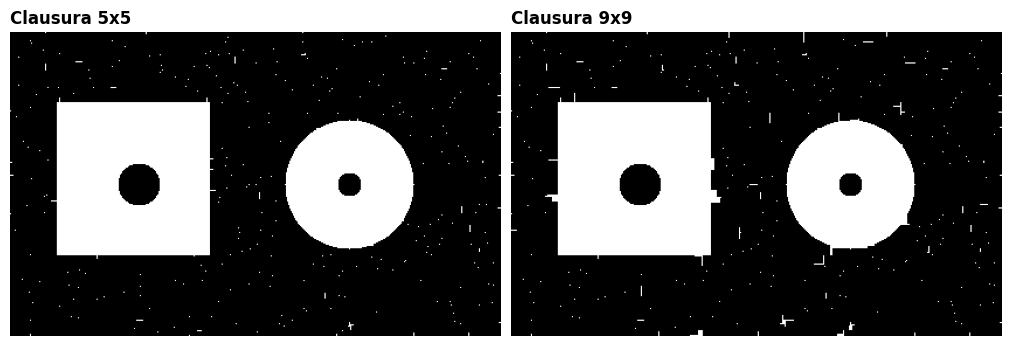

In [10]:
# La apertura combina erosión seguida de dilatación, por eso
# suele eliminar ruido blanco pequeño sin agrandar regiones.
mascara_apertura = cv2.morphologyEx(mascara_ruidosa, cv2.MORPH_OPEN, kernel, iterations=1)

# La clausura combina dilatación seguida de erosión, por eso
# tiende a cerrar huecos y conectar pequeños cortes internos.
mascara_clausura = cv2.morphologyEx(mascara_ruidosa, cv2.MORPH_CLOSE, kernel, iterations=1)

fig, ejes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)
ejes[0].imshow(mascara_ruidosa, cmap="gray")
ejes[0].set_title("M?scara ruidosa", fontweight="bold", loc="left")
ejes[0].axis("off")
ejes[1].imshow(mascara_apertura, cmap="gray")
ejes[1].set_title("Apertura", fontweight="bold", loc="left")
ejes[1].axis("off")
ejes[2].imshow(mascara_clausura, cmap="gray")
ejes[2].set_title("Clausura", fontweight="bold", loc="left")
ejes[2].axis("off")
plt.show()

# Para expandir el análisis, se prueba una clausura con un kernel mayor.
# Esto permite responder la actividad observando el efecto de aumentar la vecindad.
kernel_grande = np.ones((9, 9), dtype=np.uint8)
mascara_clausura_grande = cv2.morphologyEx(mascara_ruidosa, cv2.MORPH_CLOSE, kernel_grande, iterations=1)

fig, ejes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)
ejes[0].imshow(mascara_clausura, cmap="gray")
ejes[0].set_title("Clausura 5x5", fontweight="bold", loc="left")
ejes[0].axis("off")
ejes[1].imshow(mascara_clausura_grande, cmap="gray")
ejes[1].set_title("Clausura 9x9", fontweight="bold", loc="left")
ejes[1].axis("off")
plt.show()


Compará qué problema resuelve mejor cada operación. Si querés sacar puntitos aislados, apertura suele ser una mejor candidata. Si querés cerrar agujeros o unir partes cercanas, clausura suele ser más útil.


## 4. Transferir la idea a una imagen real

Ahora vamos a tomar una imagen con notas manuscritas, binarizarla y aplicar una clausura simple para reforzar trazos cortados.


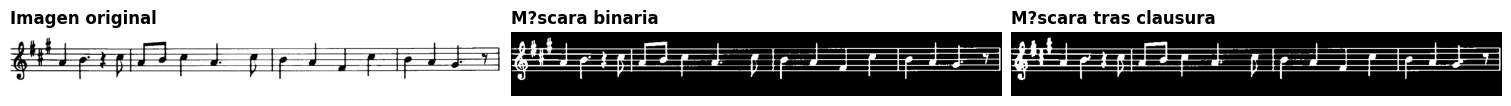

In [11]:
# Se carga la imagen real en escala de grises para segmentarla luego.
ruta_notas = Path("Imagenes") / "notes.png"
imagen_notas_gris = cv2.imread(str(ruta_notas), cv2.IMREAD_GRAYSCALE)
if imagen_notas_gris is None:
    raise FileNotFoundError(f"No se pudo leer la imagen: {ruta_notas}")

# El umbral binario inverso deja el texto claro como primer plano blanco
# y el fondo oscuro, que es el formato esperado por la morfología.
_, mascara_texto = cv2.threshold(imagen_notas_gris, 180, 255, cv2.THRESH_BINARY_INV)

# Una clausura pequeña ayuda a unir trazos cortados sin deformar demasiado
# la estructura global de las letras.
mascara_texto_limpia = cv2.morphologyEx(mascara_texto, cv2.MORPH_CLOSE, np.ones((3, 3), dtype=np.uint8), iterations=1)

fig, ejes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
ejes[0].imshow(imagen_notas_gris, cmap="gray")
ejes[0].set_title("Imagen original", fontweight="bold", loc="left")
ejes[0].axis("off")
ejes[1].imshow(mascara_texto, cmap="gray")
ejes[1].set_title("M?scara binaria", fontweight="bold", loc="left")
ejes[1].axis("off")
ejes[2].imshow(mascara_texto_limpia, cmap="gray")
ejes[2].set_title("M?scara tras clausura", fontweight="bold", loc="left")
ejes[2].axis("off")
plt.show()


## Actividad breve

Probá cambiar el tama?o del kernel en la apertura o en la clausura. Después respondé:

1. qué mejora produce el cambio?
2. qué  deformaci?n introduce?
3. cómo decidirías el tamaño del kernel en un caso real?




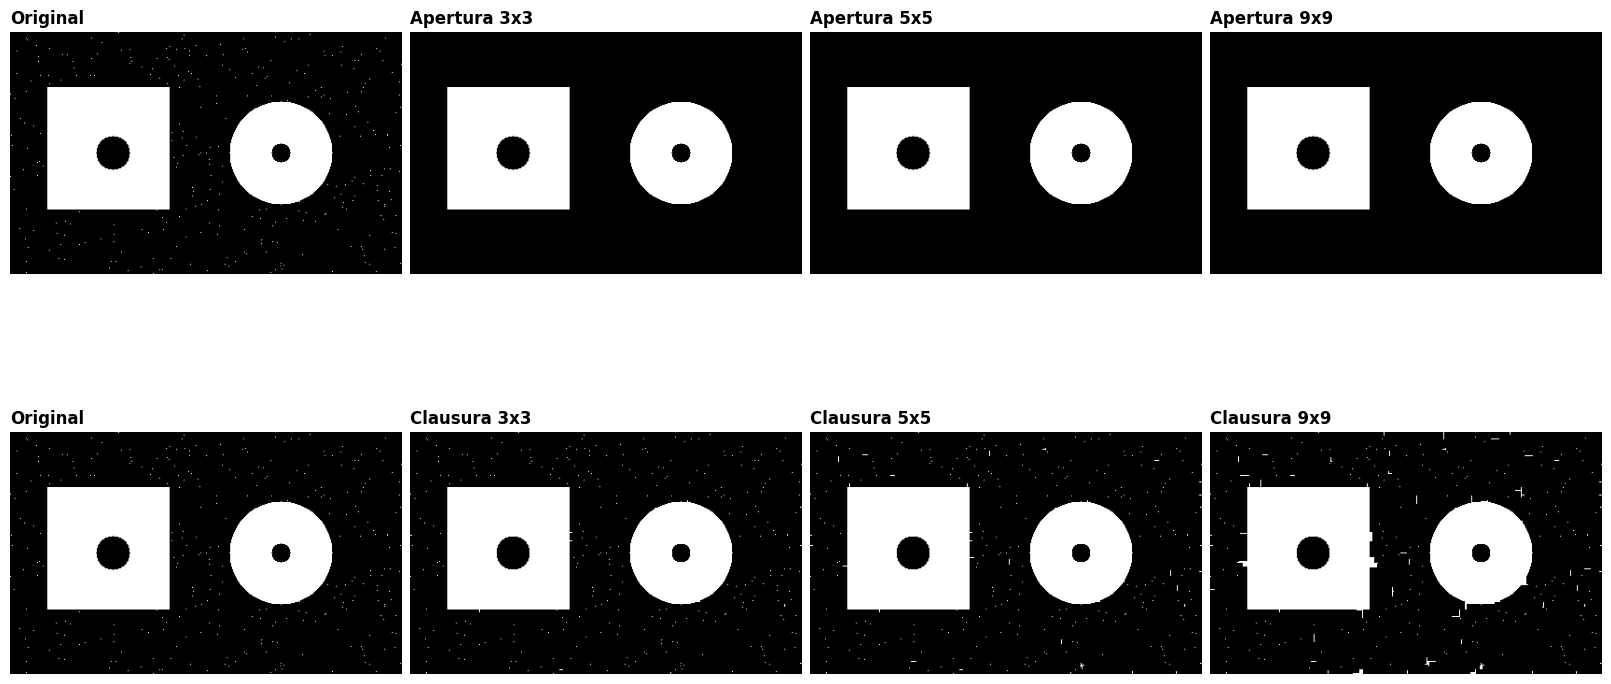

In [12]:
kernel_3 = np.ones((3, 3), dtype=np.uint8)
kernel_5 = np.ones((5, 5), dtype=np.uint8)
kernel_9 = np.ones((9, 9), dtype=np.uint8)

apertura_3 = cv2.morphologyEx(mascara_ruidosa, cv2.MORPH_OPEN, kernel_3, iterations=1)
apertura_5 = cv2.morphologyEx(mascara_ruidosa, cv2.MORPH_OPEN, kernel_5, iterations=1)
apertura_9 = cv2.morphologyEx(mascara_ruidosa, cv2.MORPH_OPEN, kernel_9, iterations=1)

clausura_3 = cv2.morphologyEx(mascara_ruidosa, cv2.MORPH_CLOSE, kernel_3, iterations=1)
clausura_5 = cv2.morphologyEx(mascara_ruidosa, cv2.MORPH_CLOSE, kernel_5, iterations=1)
clausura_9 = cv2.morphologyEx(mascara_ruidosa, cv2.MORPH_CLOSE, kernel_9, iterations=1)

fig, ejes = plt.subplots(2, 4, figsize=(16, 8), constrained_layout=True)

ejes[0, 0].imshow(mascara_ruidosa, cmap="gray")
ejes[0, 0].set_title("Original", fontweight="bold", loc="left")
ejes[0, 0].axis("off")

ejes[0, 1].imshow(apertura_3, cmap="gray")
ejes[0, 1].set_title("Apertura 3x3", fontweight="bold", loc="left")
ejes[0, 1].axis("off")

ejes[0, 2].imshow(apertura_5, cmap="gray")
ejes[0, 2].set_title("Apertura 5x5", fontweight="bold", loc="left")
ejes[0, 2].axis("off")

ejes[0, 3].imshow(apertura_9, cmap="gray")
ejes[0, 3].set_title("Apertura 9x9", fontweight="bold", loc="left")
ejes[0, 3].axis("off")

ejes[1, 0].imshow(mascara_ruidosa, cmap="gray")
ejes[1, 0].set_title("Original", fontweight="bold", loc="left")
ejes[1, 0].axis("off")

ejes[1, 1].imshow(clausura_3, cmap="gray")
ejes[1, 1].set_title("Clausura 3x3", fontweight="bold", loc="left")
ejes[1, 1].axis("off")

ejes[1, 2].imshow(clausura_5, cmap="gray")
ejes[1, 2].set_title("Clausura 5x5", fontweight="bold", loc="left")
ejes[1, 2].axis("off")

ejes[1, 3].imshow(clausura_9, cmap="gray")
ejes[1, 3].set_title("Clausura 9x9", fontweight="bold", loc="left")
ejes[1, 3].axis("off")

plt.show()


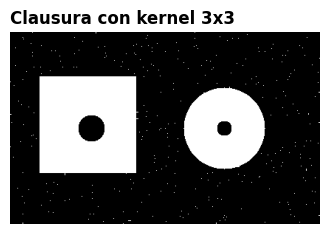

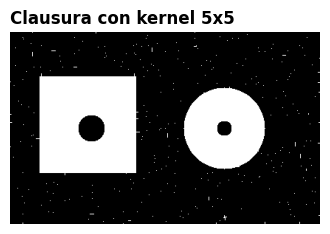

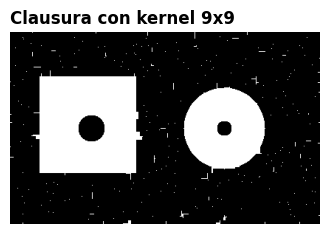

In [13]:
for tam in [3, 5, 9]:
    kernel = np.ones((tam, tam), dtype=np.uint8)
    resultado = cv2.morphologyEx(mascara_ruidosa, cv2.MORPH_CLOSE, kernel, iterations=1)

    plt.figure(figsize=(4, 4))
    plt.imshow(resultado, cmap="gray")
    plt.title(f"Clausura con kernel {tam}x{tam}", fontweight="bold", loc="left")
    plt.axis("off")
    plt.show()


Al comparar la **clausura con kernel 5x5** contra la **clausura con kernel 9x9**, se observa lo siguiente:

1. El kernel ms grande **cierra mejor huecos internos** y conecta zonas cercanas con m?s facilidad.
2. A cambio, también **deforma m?s la forma original**: redondea esquinas, engrosa bordes y puede unir regiones que en realidad convendría mantener separadas.
3. En un caso real, elegiría el tamaño del kernel mirando la **escala del defecto** que quiero corregir. El kernel debería ser apenas mayor que el ruido o corte que necesito resolver, pero no tan grande como para alterar la geometr?a principal de la máscara.


## Cierre

Las operaciones morfológicas no “limpian” imágenes en abstracto: modifican formas binarias con un criterio geométrico. Por eso conviene pensarlas siempre en relación con el defecto que querés corregir y con la tarea que viene después.
